In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

# compare model's hyperparameters

In [2]:
def compare_plot(df, col_x, col_valilla, col_jimmy, y_label, title=""):
    x = df[col_x]
    y_vanilla = df[col_valilla]
    y_jimmy = df[col_jimmy]
    y_all = df[[col_valilla, col_jimmy]]

    fig = plt.figure(figsize=(12,6))
    plt.title(title)

    plt.plot(x, y_vanilla, zorder=3, markeredgecolor="black", alpha=0.4, linewidth=2)
    plt.plot(x, y_jimmy, zorder=3, markeredgecolor="black", alpha=0.4, linewidth=2)

    plt.scatter(x, y_vanilla, zorder=3, label="ColabNAS")
    plt.scatter(x, y_jimmy, zorder=3, label="FCNNAS")

    # width = 0.3
    # xmin = [i - width/2 for i in range(len(x))]
    # xmax = [i + width/2 for i in range(len(x))]
    
    # plt.ylim(0.3, 1.0)

    # plt.hlines(y=y_vanilla, xmin=xmin, xmax=xmax, color='black', linewidth=1, zorder=2)
    # plt.hlines(y=y_jimmy, xmin=xmin, xmax=xmax, color='black', linewidth=1, zorder=2)

    # plt.grid(axis="x",zorder=2)
    # plt.grid(axis="y",zorder=2, linestyle= (0, (2, 10)))
    
    plt.grid(axis="x",zorder=2, linestyle= "--")
    plt.grid(axis="y",zorder=2, linestyle= "--")

    plt.xticks(rotation=15)
    plt.xlabel("Hyperparameter (K: Kernel, C: Cell)")
    plt.ylabel(y_label)
    plt.legend()

    return fig
    


In [3]:
dataset_paths = [path for path in Path("../Experiments_Compare_Model").iterdir() if path.is_dir()]
log_filname = "model_log.csv"

In [4]:
visualize_pic_path = Path("visualize_result")
visualize_pic_path.mkdir(parents=True, exist_ok=True)

In [5]:
metrices = {
        "best_acc": {"y_label":"Accuracy"}, 
        "tflite_acc": {"y_label":"Accuracy"}
        }
col_x = "decision_variable"
vanilla_name = "vanillaNAS_dense_"
jimmy_name = "JimmyNAS_I_fullyCNN_"
for dataset_path in dataset_paths:
    output_path = (visualize_pic_path/dataset_path.name)
    output_path.mkdir(parents=True, exist_ok=True)
    df = pd.read_csv(dataset_path/log_filname)
    print(dataset_path.name)
    temp_dict = {metric:{"vanilla":vanilla_name+metric, "jimmy":jimmy_name+metric}for metric in metrices.keys()}
    for key, value in temp_dict.items():
        fig = compare_plot(df, col_x, value["vanilla"], value["jimmy"], metrices[key]["y_label"])
        fig.savefig(output_path/f"{key}.png", dpi=300, bbox_inches='tight')
        plt.close(fig)

Animals-3
Flowers-4
MelanomaSkinCancer
MNIST
visual_wake_words


In [6]:
col_x = "decision_variable"
metrices = {
    "macs": {"y_label":"MACC"},
    "flash": {"y_label":"Flash (Byte)"}, 
    "peak_ram": {"y_label":"Peak RAM (Byte)"}, 
    "param_count": {"y_label":"Parameters"}
    }
vanilla_name = "vanillaNAS_dense_"
jimmy_name = "JimmyNAS_I_fullyCNN_"
for dataset_path in dataset_paths:
    output_path.mkdir(parents=True, exist_ok=True)
    df = pd.read_csv(dataset_path/log_filname)
    print(dataset_path.name)
    temp_dict = {metric:{"vanilla":vanilla_name+metric, "jimmy":jimmy_name+metric}for metric in metrices.keys()}
    for key, value in temp_dict.items():
        fig = compare_plot(df, col_x, value["vanilla"], value["jimmy"], metrices[key]["y_label"])
        fig.savefig(visualize_pic_path/f"{key}.png", dpi=300, bbox_inches='tight')
        plt.close(fig)
        
    break # use only 1 dataset to get model properties

Animals-3


# compare model kfold

In [7]:
# def kfold_plot(df, col_x, col_valilla, col_jimmy, y_label, title=""):
#     x = df[col_x]
#     y_vanilla = df[col_valilla]
#     y_jimmy = df[col_jimmy]
#     y_all = df[[col_valilla, col_jimmy]]

#     fig = plt.figure(figsize=(12,6))
#     plt.title(title)

#     # plt.plot(x, y_vanilla, zorder=3, markeredgecolor="black", alpha=0.25)
#     # plt.plot(x, y_jimmy, zorder=3, markeredgecolor="black", alpha=0.25)

#     plt.scatter(x, y_vanilla, zorder=3, label="vanillaNAS")
#     plt.scatter(x, y_jimmy, zorder=3, label="JimmyNAS")

#     width = 0.3
#     xmin = [i - width/2 for i in range(len(x))]
#     xmax = [i + width/2 for i in range(len(x))]

#     plt.hlines(y=y_vanilla, xmin=xmin, xmax=xmax, color='black', linewidth=1, zorder=2)
#     plt.hlines(y=y_jimmy, xmin=xmin, xmax=xmax, color='black', linewidth=1, zorder=2)

#     plt.grid(axis="x",zorder=2)
#     plt.grid(axis="y",zorder=2, linestyle= (0, (2, 10)))

#     plt.xticks(rotation=15)
#     plt.xlabel("Hyperparameter (K: Kernel, C: Cell)")
#     plt.ylabel(y_label)
#     plt.legend()

#     return fig
    


In [8]:

# def kfold_plot(df, col_x, col_valilla, col_jimmy, y_label, metric, title=""):
#     fig = plt.figure(figsize=(12,6))
#     plt.title(title)
    
#     df = df[[col_x, col_valilla, col_jimmy]]
#     df_temp = df[["k-fold"]].merge(pd.DataFrame(df.iloc[:,1:].T.index), how="cross")
#     df_temp.rename(columns={0:"model"}, inplace=True)
#     df_temp["model"] = df_temp["model"].str.split(metric).apply(lambda x : x[0][:-1])
#     df_temp[metric] = pd.NA
#     df_temp.loc[df_temp["model"]=="vanillaNAS_dense", [metric]] = df[col_valilla].values
#     df_temp.loc[df_temp["model"]=="JimmyNAS_I_fullyCNN", [metric]] = df[col_jimmy].values
#     df_temp.loc[df_temp["model"]=="vanillaNAS_dense", "model"] = "vanillaNAS"
#     df_temp.loc[df_temp["model"]=="JimmyNAS_I_fullyCNN", "model"] = "FCNNAS"
#     # One line to rule them all
#     ax = sns.barplot(data=df_temp, x=col_x, y=metric, hue='model')

#     # Iterate through the containers and add labels
#     for container in ax.containers:
#         ax.bar_label(container, padding=3)

#     offset = (df_temp[metric].max() - df_temp[metric].min())*0.2
#     if metric in ["tflite_acc", "tflite_precision", "tflite_recall", "tflite_f1"]:
#         plt.ylim(0, df_temp[metric].max()+0.1)
#     else:
#         plt.ylim(df_temp[metric].min()-offset, df_temp[metric].max()+offset)
#     plt.grid(axis="y", ls="-", alpha=0.5)
#     plt.ylabel(y_label)
#     return fig
    


In [9]:

def kfold_plot(df, col_x, col_valilla, col_jimmy, y_label, metric, title=""):
    fig = plt.figure(figsize=(12,6))
    plt.title(title)
    
    df = df[[col_x, col_valilla, col_jimmy]]
    df_temp = df[["k-fold"]].merge(pd.DataFrame(df.iloc[:,1:].T.index), how="cross")
    df_temp.rename(columns={0:"model"}, inplace=True)
    df_temp["model"] = df_temp["model"].str.split(metric).apply(lambda x : x[0][:-1])
    df_temp[metric] = pd.NA
    df_temp.loc[df_temp["model"]=="vanillaNAS_dense", [metric]] = df[col_valilla].values
    df_temp.loc[df_temp["model"]=="JimmyNAS_I_fullyCNN", [metric]] = df[col_jimmy].values
    df_temp.loc[df_temp["model"]=="vanillaNAS_dense", "model"] = "ColabNAS"
    df_temp.loc[df_temp["model"]=="JimmyNAS_I_fullyCNN", "model"] = "FCNNAS"
    # One line to rule them all
    ax = sns.barplot(data=df_temp, x=metric, y=col_x, hue='model')

    # Iterate through the containers and add labels
    for container in ax.containers:
        ax.bar_label(container, padding=3)

    offset = (df_temp[metric].max() - df_temp[metric].min())*0.2
    if metric in ["tflite_acc", "tflite_precision", "tflite_recall", "tflite_f1"]:
        plt.xlim(0.5, 1.05)
        plt.xticks([0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0])
    else:
        plt.xlim(df_temp[metric].min()-offset, df_temp[metric].max()+offset)
    # plt.grid(axis="x", ls="-", alpha=0.5)
    plt.xlabel(y_label)
    return fig
    


In [10]:
dataset_paths = [path for path in Path("../Experiments_KFolds2").iterdir() if path.is_dir()]
log_filname = "models_log.csv"

In [11]:
visualize_pic_path = Path("visualize_result")
visualize_pic_path.mkdir(parents=True, exist_ok=True)

In [12]:

metrices = {
        "best_acc": {"y_label":"Accuracy"}, 
        "tflite_acc": {"y_label":"Accuracy"},
        "tflite_precision": {"y_label":"Precision"},
        "tflite_recall": {"y_label":"Recall"},
        "tflite_f1": {"y_label":"F1-score"},
        "param_count": {"y_label":"Parameters"},
        "mac_count": {"y_label":"MACC"},
        "flash": {"y_label":"Flash (Byte)"},
        "peak_ram": {"y_label":"Peak RAM(Byte)"},
        }

col_x = "k-fold"
vanilla_name = "vanillaNAS_dense_"
jimmy_name = "JimmyNAS_I_fullyCNN_"
for dataset_path in dataset_paths:
    output_path = (visualize_pic_path/Path(dataset_path.name)/"kfold")
    output_path.mkdir(parents=True, exist_ok=True)
    df = pd.read_csv(dataset_path/log_filname)
    print(dataset_path.name)
    temp_dict = {metric:{"vanilla":vanilla_name+metric, "jimmy":jimmy_name+metric} for metric in metrices.keys()}
    for key, value in temp_dict.items():
        fig = kfold_plot(df, col_x, value["vanilla"], value["jimmy"], metrices[key]["y_label"], metric=key)
        fig.savefig(output_path/f"{key}.png", dpi=300, bbox_inches='tight')
        plt.close(fig)

Animals-3
Flowers-4
MelanomaSkinCancer
MNIST
visual_wake_words


# subplots

In [56]:
def compare_plot_constraint(ax, col_x, col_valilla, col_jimmy, y_label, title=""):
    
    map_title = {
    "param_count": "Parameter Count",
    "macs": "Multiply-Accumulate",
    "peak_ram": "Peak RAM Used", 
    "flash": "Flash Used", 
    }
    x = df[col_x]
    y_vanilla = df[col_valilla]
    y_jimmy = df[col_jimmy]
    y_all = df[[col_valilla, col_jimmy]]

    ax.set_title(map_title[title])

    ax.plot(x, y_vanilla, zorder=3, markeredgecolor="black", alpha=0.75, linewidth=2)
    ax.plot(x, y_jimmy, zorder=3, markeredgecolor="black", alpha=0.75, linewidth=2)

    ax.scatter(x, y_vanilla, zorder=3, label="ColabNAS", s=45)
    ax.scatter(x, y_jimmy, zorder=3, label="FCNNAS", s=45)
    
    ax.grid(axis="x",zorder=2, linestyle= "--")
    ax.grid(axis="y",zorder=2, linestyle= "--")

    ax.tick_params(axis='x', rotation=45, pad=2, labelsize = 8)
    if title in ["peak_ram", "flash"]:
        ax.set_xlabel("Hyperparameter (K: Kernel, C: Cell)", fontsize=12)
    ax.set_ylabel(y_label)
    # ax.legend()

    return fig

def compare_plot_acc(ax, col_x, col_valilla, col_jimmy, y_label, title=""):
    
    map_title = {
    "Animals-3": "Accuracy on Animals-3",
    "visual_wake_words": "Accuracy on Visual Wake Worlds",
    }
    
    x = df[col_x]
    y_vanilla = df[col_valilla]
    y_jimmy = df[col_jimmy]
    y_all = df[[col_valilla, col_jimmy]]

    ax.set_title(map_title[title])

    ax.plot(x, y_vanilla, zorder=3, markeredgecolor="black", alpha=0.75, linewidth=2)
    ax.plot(x, y_jimmy, zorder=3, markeredgecolor="black", alpha=0.75, linewidth=2)

    ax.scatter(x, y_vanilla, zorder=3, label="ColabNAS", s=45)
    ax.scatter(x, y_jimmy, zorder=3, label="FCNNAS", s=45)
    
    ax.grid(axis="x",zorder=2, linestyle= "--")
    ax.grid(axis="y",zorder=2, linestyle= "--")

    ax.tick_params(axis='x', rotation=45, pad=2, labelsize = 8)
    if title in ["visual_wake_words"]:
        ax.set_xlabel("Hyperparameter (K: Kernel, C: Cell)", fontsize=12)
    ax.set_ylabel(y_label)
    ax.set_ylim(0.4, 1)
    # ax.legend(loc="upper left")

    return fig
    


In [14]:
dataset_paths = [path for path in Path("../Experiments_Compare_Model").iterdir() if path.is_dir()]
log_filname = "model_log.csv"

In [15]:
visualize_pic_path = Path("visualize_result")
visualize_pic_path.mkdir(parents=True, exist_ok=True)

Animals-3
Animals-3
visual_wake_words


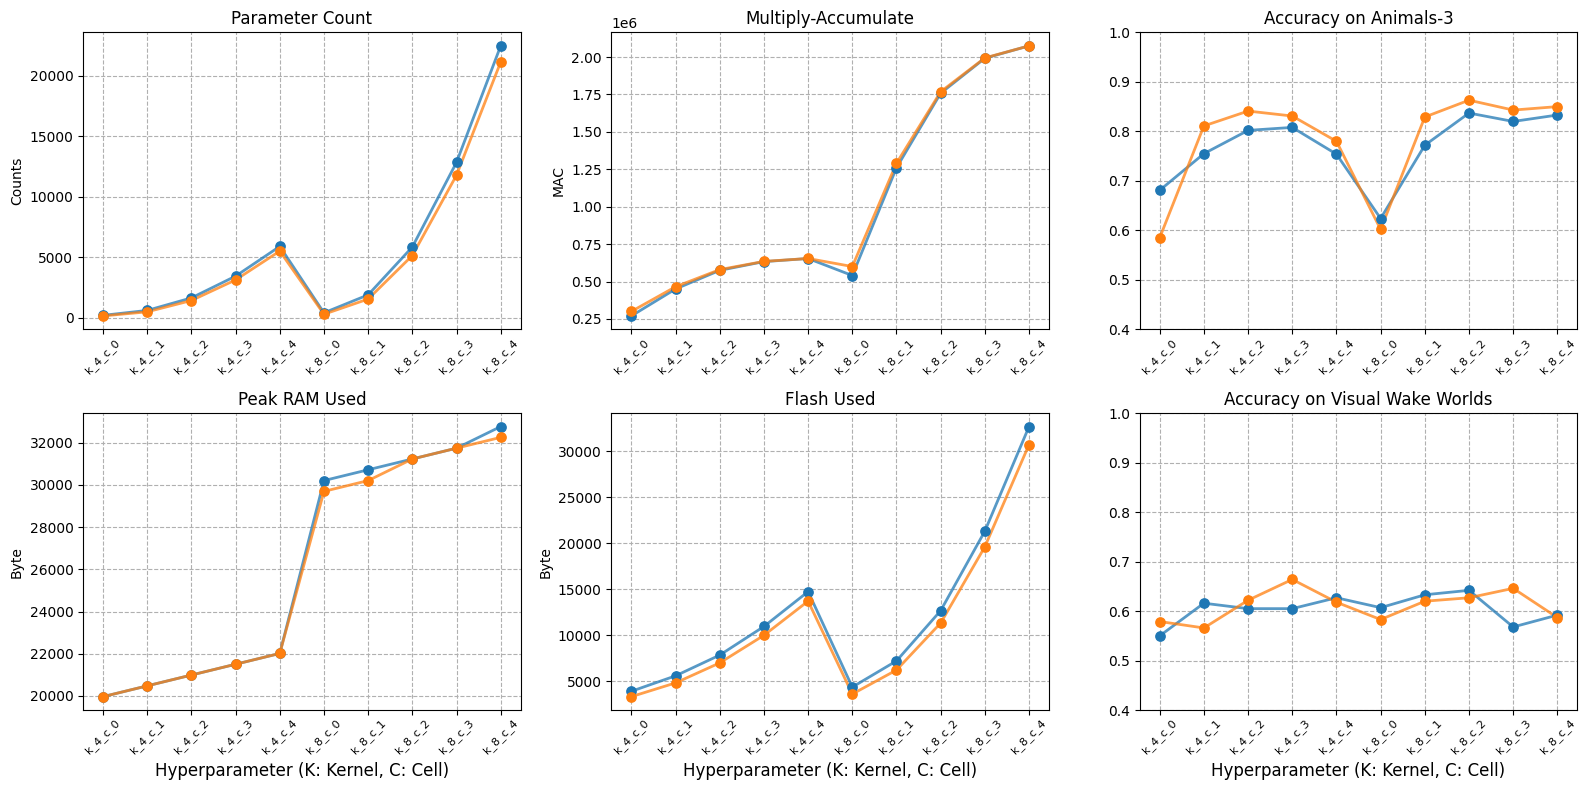

In [ ]:

n_row = 2
n_col = 3
fig, axes = plt.subplots(n_row, n_col, figsize = (16, 8))
# fig.subplots_adjust(hspace=0.25, wspace=0.15)
# axes = axes.flatten()
axes_1 = axes[:,:2]
axes_1 = axes_1.flatten()
axes_2 = axes[:,2:]
axes_2 = axes_2.flatten()

vanilla_name = "vanillaNAS_dense_"
jimmy_name = "JimmyNAS_I_fullyCNN_"
col_x = "decision_variable"

metrices = {
    "param_count": {"y_label":"Counts"},
    "macs": {"y_label":"MAC"},
    "peak_ram": {"y_label":"Byte"}, 
    "flash": {"y_label":"Byte"}, 
    }

for dataset_path in dataset_paths:
    df = pd.read_csv(dataset_path/log_filname)
    print(dataset_path.name)
    temp_dict = {metric:{"vanilla":vanilla_name+metric, "jimmy":jimmy_name+metric}for metric in metrices.keys()}
    i=0
    for key, value in temp_dict.items():
        compare_plot_constraint(axes_1[i], col_x, value["vanilla"], value["jimmy"], metrices[key]["y_label"], key)
        i+=1
    break

metrices = {
        "tflite_acc": {"y_label":""}
        }
vanilla_name = "vanillaNAS_dense_"
jimmy_name = "JimmyNAS_I_fullyCNN_"
i=0
for dataset_path in dataset_paths:
    if dataset_path.name in ["Animals-3", "visual_wake_words"]:
        df = pd.read_csv(dataset_path/log_filname)
        print(dataset_path.name)
        temp_dict = {metric:{"vanilla":vanilla_name+metric, "jimmy":jimmy_name+metric}for metric in metrices.keys()}
        for key, value in temp_dict.items():
            compare_plot_acc(axes_2[i], col_x, value["vanilla"], value["jimmy"], metrices[key]["y_label"], dataset_path.name)
        i+=1

plt.tight_layout()
fig.savefig("Poster.svg", dpi=600)

In [17]:
def compare_plot_constraint(ax, col_x, col_valilla, col_jimmy, y_label, title=""):
    
    map_title = {
    "param_count": "Parameter Count",
    "macs": "Multiply-Accumulate",
    "peak_ram": "Peak RAM Used", 
    "flash": "Flash Used", 
    }
    x = df[col_x]
    y_vanilla = df[col_valilla]
    y_jimmy = df[col_jimmy]
    y_all = df[[col_valilla, col_jimmy]]

    ax.set_title(map_title[title], fontsize = 18)

    ax.plot(x, y_vanilla, zorder=3, markeredgecolor="black", alpha=0.75, linewidth=2)
    ax.plot(x, y_jimmy, zorder=3, markeredgecolor="black", alpha=0.75, linewidth=2)

    ax.scatter(x, y_vanilla, zorder=3, label="ColabNAS", s=45)
    ax.scatter(x, y_jimmy, zorder=3, label="FCNNAS", s=45)
    
    ax.grid(axis="x",zorder=2, linestyle= "--")
    ax.grid(axis="y",zorder=2, linestyle= "--")

    ax.tick_params(axis='x', rotation=25, pad=2)
    ax.set_ylabel(y_label, fontsize = 12)
    # ax.legend()

    return fig

def compare_plot_acc(ax, col_x, col_valilla, col_jimmy, y_label, title=""):
    
    map_title = {
    "Animals-3": "Accuracy on Animals-3",
    "visual_wake_words": "Accuracy on Visual Wake Worlds",
    }
    
    x = df[col_x]
    y_vanilla = df[col_valilla]
    y_jimmy = df[col_jimmy]
    y_all = df[[col_valilla, col_jimmy]]

    ax.set_title(map_title[title], fontsize = 18)

    ax.plot(x, y_vanilla, zorder=3, markeredgecolor="black", alpha=0.75, linewidth=2)
    ax.plot(x, y_jimmy, zorder=3, markeredgecolor="black", alpha=0.75, linewidth=2)

    ax.scatter(x, y_vanilla, zorder=3, label="ColabNAS", s=45)
    ax.scatter(x, y_jimmy, zorder=3, label="FCNNAS", s=45)
    
    ax.grid(axis="x",zorder=2, linestyle= "--")
    ax.grid(axis="y",zorder=2, linestyle= "--")

    ax.tick_params(axis='x', rotation=25, pad=2)
    ax.set_xlabel("Hyperparameter (K: Kernel, C: Cell)", fontsize = 12, labelpad=20)
    ax.set_ylabel(y_label, fontsize = 12)
    ax.set_ylim(0.4, 1)
    # ax.legend(loc="upper left")

    return fig
    


In [18]:
dataset_paths = [path for path in Path("../Experiments_Compare_Model").iterdir() if path.is_dir()]
log_filname = "model_log.csv"

In [19]:
visualize_pic_path = Path("visualize_result")
visualize_pic_path.mkdir(parents=True, exist_ok=True)

Animals-3
Animals-3
visual_wake_words


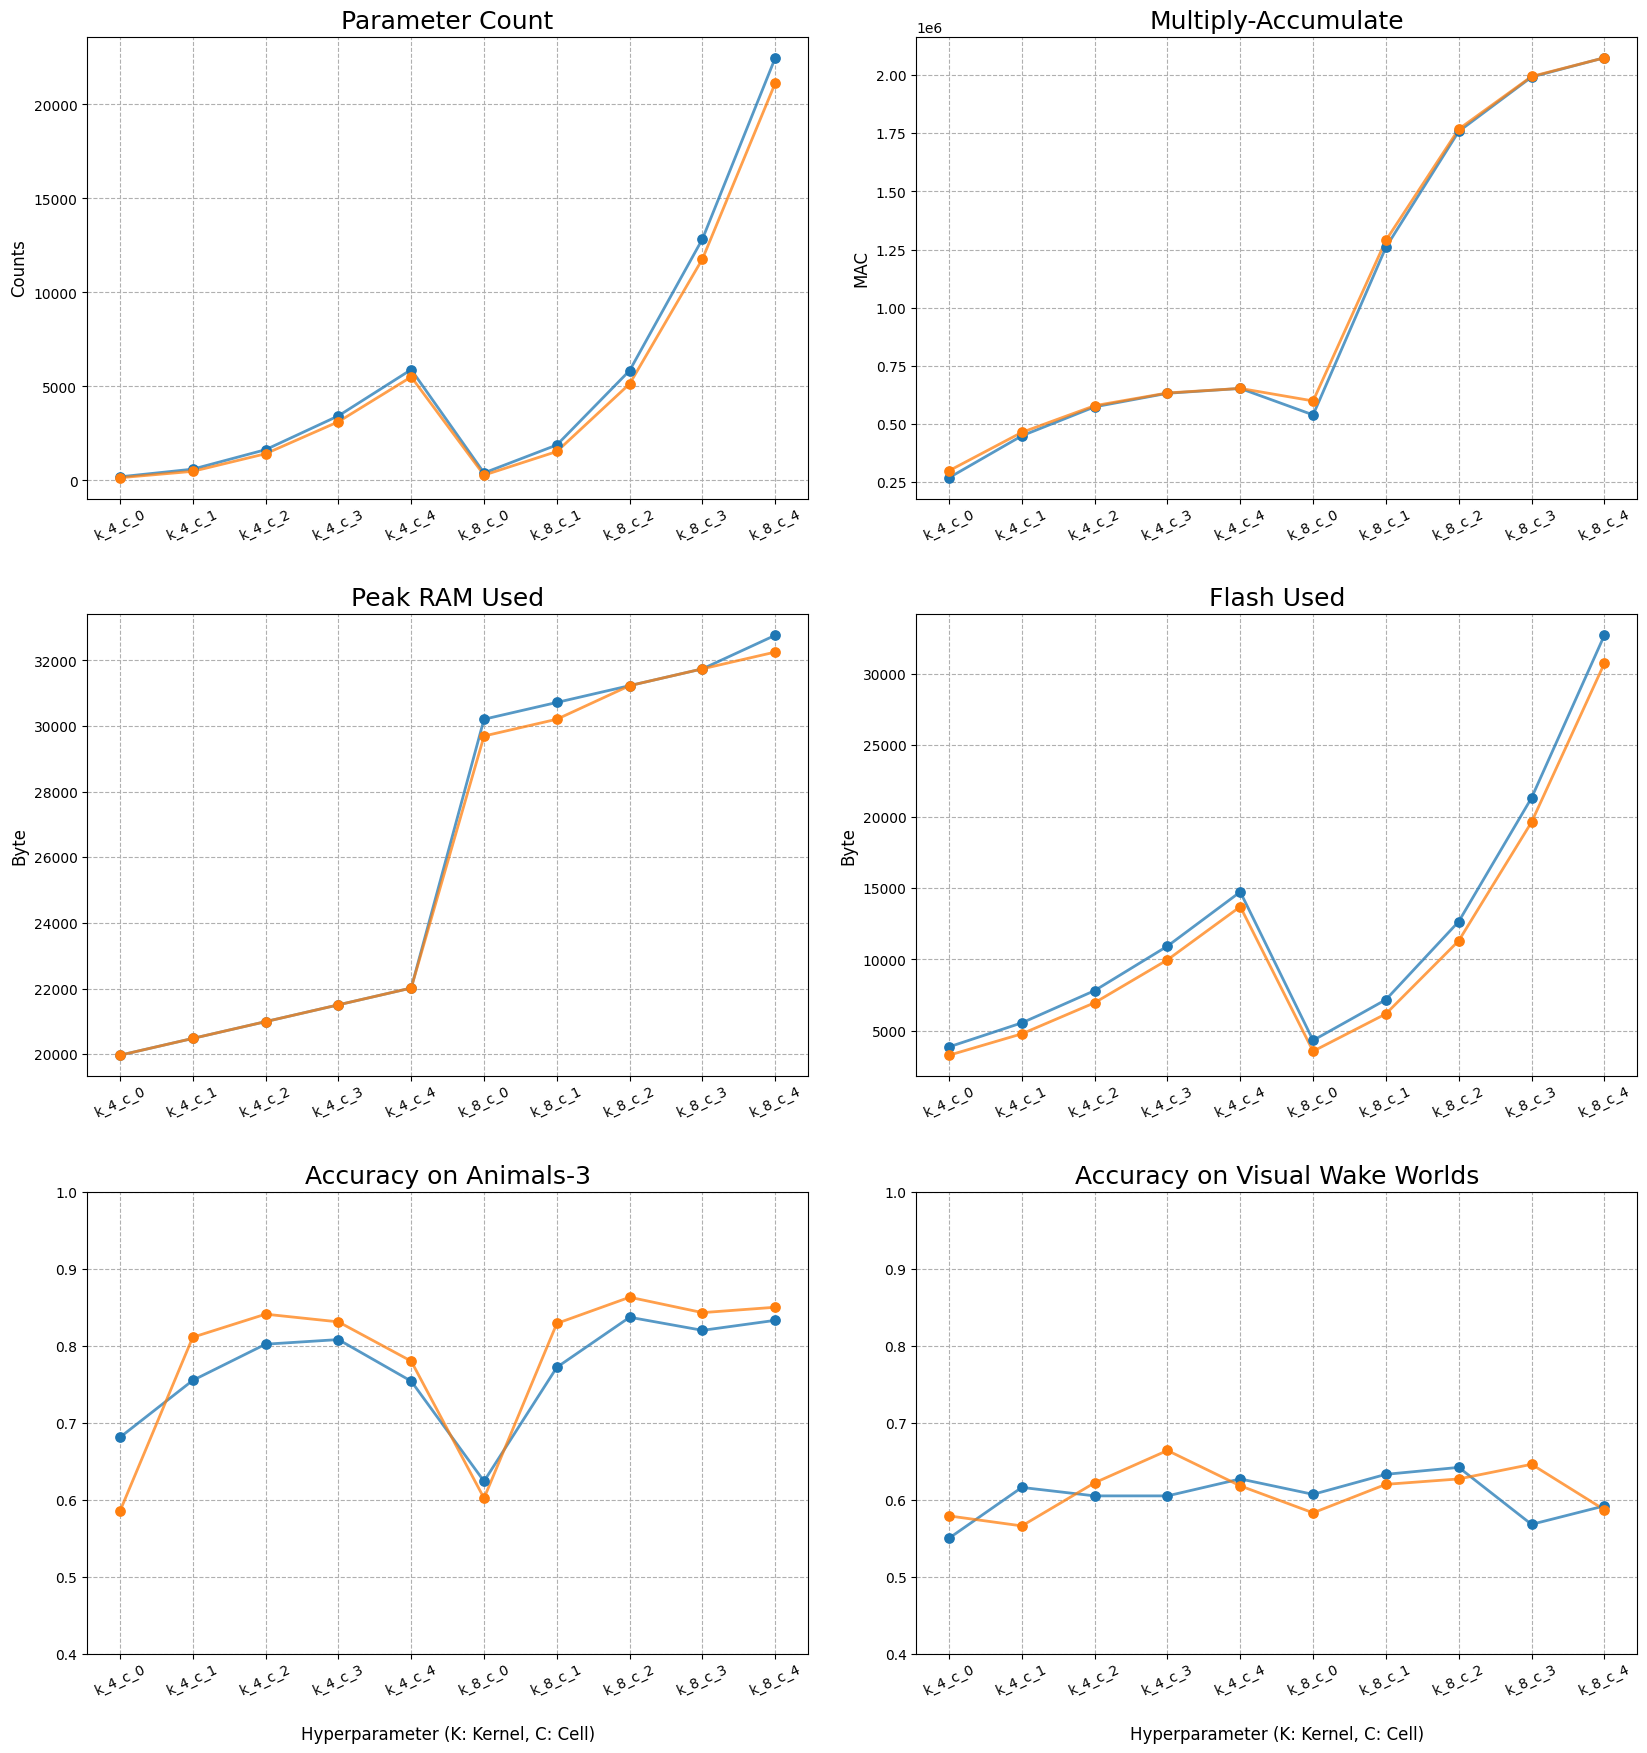

In [20]:

n_row = 3
n_col = 2
fig, axes = plt.subplots(n_row, n_col, figsize = (n_col*10, n_row*7))
fig.subplots_adjust(hspace=0.25, wspace=0.15)
# axes = axes.flatten()
axes_1 = axes[:2,:]
axes_1 = axes_1.flatten()
axes_2 = axes[2:,:]
axes_2 = axes_2.flatten()

vanilla_name = "vanillaNAS_dense_"
jimmy_name = "JimmyNAS_I_fullyCNN_"
col_x = "decision_variable"

metrices = {
    "param_count": {"y_label":"Counts"},
    "macs": {"y_label":"MAC"},
    "peak_ram": {"y_label":"Byte"}, 
    "flash": {"y_label":"Byte"}, 
    }

for dataset_path in dataset_paths:
    df = pd.read_csv(dataset_path/log_filname)
    print(dataset_path.name)
    temp_dict = {metric:{"vanilla":vanilla_name+metric, "jimmy":jimmy_name+metric}for metric in metrices.keys()}
    i=0
    for key, value in temp_dict.items():
        compare_plot_constraint(axes_1[i], col_x, value["vanilla"], value["jimmy"], metrices[key]["y_label"], key)
        i+=1
    break

metrices = {
        "tflite_acc": {"y_label":""}
        }
vanilla_name = "vanillaNAS_dense_"
jimmy_name = "JimmyNAS_I_fullyCNN_"
i=0
for dataset_path in dataset_paths:
    if dataset_path.name in ["Animals-3", "visual_wake_words"]:
        df = pd.read_csv(dataset_path/log_filname)
        print(dataset_path.name)
        temp_dict = {metric:{"vanilla":vanilla_name+metric, "jimmy":jimmy_name+metric}for metric in metrices.keys()}
        for key, value in temp_dict.items():
            compare_plot_acc(axes_2[i], col_x, value["vanilla"], value["jimmy"], metrices[key]["y_label"], dataset_path.name)
        i+=1


# plt.tight_layout()
# plt.show()
fig.savefig(fname = "Poster2.png", dpi=600)